<a href="https://colab.research.google.com/github/JFVadiaz25/Laboratorio2Parte1Auto2/blob/main/Laboratorio2Parte1NeumoNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Laboratorio 2 Parte 1 Automatización 2 </h1>
<h2>Deep Learning</h2>


<h1> Exploración y análisis del dataset </h1>


In [ ]:
%pip install kagglehub

import kagglehub
from PIL import Image
import os

# Descargar dataset con manejo de error de conexión
try:
    path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    print("Path to dataset files:", path)
except Exception as e:
    print("Error al descargar el dataset:", e)
    print("Verifica tu conexión a internet y vuelve a intentarlo más tarde.")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
print("Path to dataset files:", path)
print(os.listdir(os.path.join(path, "chest_xray")))

Path to dataset files: /kaggle/input/chest-xray-pneumonia/chest_xray
['val', '.DS_Store', 'test', 'train']


In [ ]:
# Ruta dataset
path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Contar imágenes por clase
print("\nCANTIDAD DE IMÁGENES")
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:")
    for clase in ['NORMAL', 'PNEUMONIA']:
        clase_path = os.path.join(path, split, clase)
        if os.path.exists(clase_path):
            num_images = len(os.listdir(clase_path))
            print(f"  {clase}: {num_images} imágenes")


CANTIDAD DE IMÁGENES

TRAIN:
  NORMAL: 1341 imágenes
  PNEUMONIA: 3875 imágenes

TEST:
  NORMAL: 234 imágenes
  PNEUMONIA: 390 imágenes

VAL:
  NORMAL: 8 imágenes
  PNEUMONIA: 8 imágenes


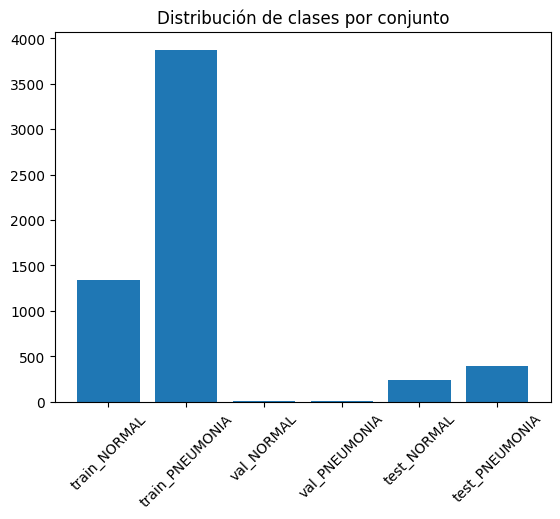

In [ ]:
import matplotlib.pyplot as plt

datos = {'train_NORMAL': 1342, 'train_PNEUMONIA': 3876,
         'val_NORMAL': 9, 'val_PNEUMONIA': 9,
         'test_NORMAL': 234, 'test_PNEUMONIA': 390}

plt.bar(datos.keys(), datos.values())
plt.xticks(rotation=45)
plt.title('Distribución de clases por conjunto')
plt.show()

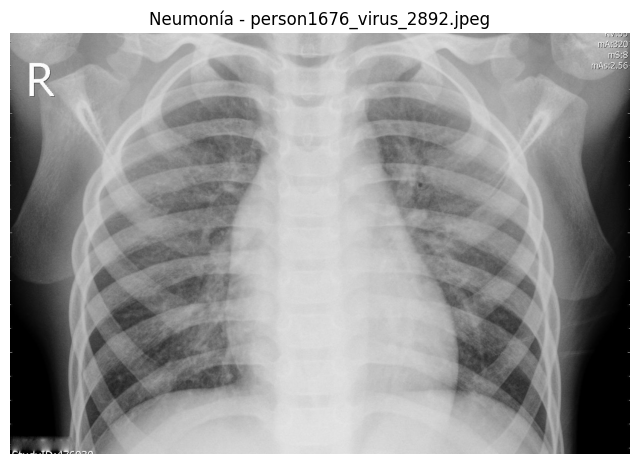

Imagen mostrada: person1676_virus_2892.jpeg


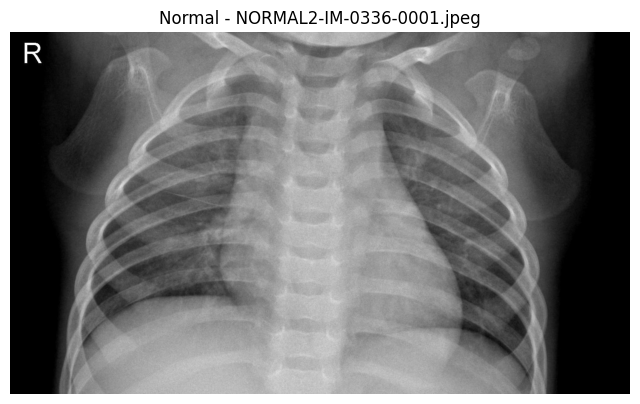

Imagen mostrada: NORMAL2-IM-0336-0001.jpeg


In [ ]:
from tensorflow.keras.preprocessing import image

# Cargar una imagen de ejemplo (PNEUMONIA)
pneumonia_path = os.path.join(path, 'test', 'PNEUMONIA')
imagen_ejemplo_pneumonia = os.listdir(pneumonia_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_pneumonia = os.path.join(pneumonia_path, imagen_ejemplo_pneumonia)

# Cargar una imagen de ejemplo (NORMAL)
normal_path = os.path.join(path, 'test', 'NORMAL')
imagen_ejemplo_normal = os.listdir(normal_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_normal = os.path.join(normal_path, imagen_ejemplo_normal)

# Cargar y mostrar imagen (PNEUMONIA)
i = image.load_img(img_completa_pneumonia)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Neumonía - {imagen_ejemplo_pneumonia}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_pneumonia}")

# Cargar y mostrar imagen (NORMAL)
i = image.load_img(img_completa_normal)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Normal - {imagen_ejemplo_normal}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_normal}")

In [ ]:
# Función para analizar una imagen
def analizar_imagen(ruta_img):
    img = image.load_img(ruta_img)

    print("FORMATO DE DATOS\n")
    print(f"Nombre del archivo: {os.path.basename(ruta_img)}")
    print(f"Ruta completa: {ruta_img}")
    print(f"Formato de archivo: {img.format}")      # No muestra formato (None) porque ya paso por image.load_img()
    print(f"Dimensiones (ancho x alto): {img.size}")  # (ancho, alto)
    print(f"Modo (canales): {img.mode}")            # L = escala de grises, RGB = color
    print(f"Tamaño del archivo: {os.path.getsize(ruta_img) / 1024:.2f} KB")
    print("-" * 50)

# Analizar imágenes de ejemplo
analizar_imagen(img_completa_pneumonia)
analizar_imagen(img_completa_normal)

# Ruta base (en Kaggle)
pneumonia_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# Ver el formato
imagen_neumonia = Image.open(pneumonia_path)
print(f"Formato de archivo: {imagen_neumonia.format}")

FORMATO DE DATOS

Nombre del archivo: person1676_virus_2892.jpeg
Ruta completa: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1624, 1104)
Modo (canales): RGB
Tamaño del archivo: 174.92 KB
--------------------------------------------------
FORMATO DE DATOS

Nombre del archivo: NORMAL2-IM-0336-0001.jpeg
Ruta completa: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0336-0001.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1612, 941)
Modo (canales): RGB
Tamaño del archivo: 126.65 KB
--------------------------------------------------
Formato de archivo: JPEG


**Análisis del dataset**

**Contenido del dataset:**

El dataset está organizado en tres carpetas principales: Train, Validation y Test.
Cada una contiene dos subcarpetas correspondientes a las clases Neumonía y Normal.
En total, el conjunto incluye 5.860 imágenes de rayos X en formato JPEG, distribuidas en las dos categorías mencionadas.

**Reto principal del dataset:**

Al analizar la distribución de las imágenes, se observa un marcado desbalance entre clases, donde la cantidad de radiografías de Neumonía supera ampliamente a las de Normal, especialmente en el conjunto de entrenamiento.

Este desbalance puede generar un sesgo en el aprendizaje del modelo, llevándolo a favorecer la predicción de la clase mayoritaria y reduciendo su capacidad para identificar correctamente los casos normales.Tambien se observo un conjuto de validación demasiado pequeño en comparación con los otros dos.

En cuanto a la resolución de las imágenes, con un chequeo general visualizamos que hay una buena resolución y esto se respalda por la descripción misma del dataset, ya que como en esta se menciona; para el análisis de las radiografías de tórax, todas se sometieron a un control de calidad inicial, eliminando todas las imágenes de baja calidad o ilegibles.


<h1>Implementación de DataLoader </h1>

Se usara un pipeline estandar de Pytorch para Dataloader, que es (imageFolder+ DataLoader)

En PyTorch, DataLoader es una clase integrada que proporciona una forma eficiente y flexible de cargar datos en un modelo para entrenamiento o inferencia. Es especialmente útil para gestionar grandes conjuntos de datos que no caben en la memoria, así como para realizar el preprocesamiento y la ampliación de datos.

In [ ]:
print(os.listdir(path))
print(os.listdir(os.path.join(path, "chest_xray")))

['chest_xray']
['chest_xray', '__MACOSX', 'val', 'test', 'train']


Ahora vamos a definir las rutas principales del dataset

In [ ]:
data_root = os.path.join(path, "chest_xray")

train_dir = os.path.join(data_root, "train")
val_dir = os.path.join(data_root, "val")
test_dir = os.path.join(data_root, "test")

print("Entrenamiento:", train_dir)
print("Validación:", val_dir)
print("Prueba:", test_dir)


Entrenamiento: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validación: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Prueba: /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformaciones para preparar las imágenes
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # aqui se escala las imágenes
    transforms.ToTensor(),           # Convierte a tensores (PyTorch) investigar más para sustentar
])

# Cargar datasets. PyTorch asigna automáticamente un número entero a cada clase basándose en el orden alfabético de las carpetas dentro del directorio.
train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

# Crear DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print("DataLoaders creados correctamente ")


DataLoaders creados correctamente 


El parámetro batch_size determina cuántas muestras se procesan simultáneamente antes de realizar una actualización de los pesos del modelo.

Ahora comprobamos que los lotes estén cargando bien

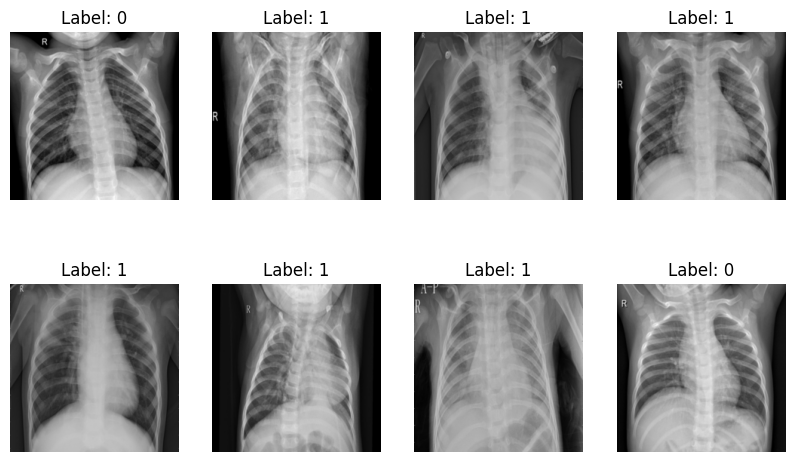

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener un batch
images, labels = next(iter(train_loader))

# Mostrar primeras 8 imágenes del batch
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.show()


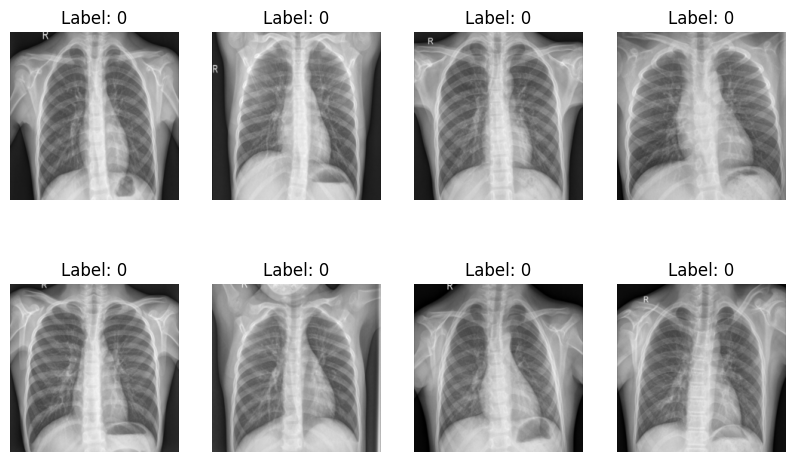

In [ ]:
# Obtener un batch
images, labels = next(iter(test_loader))

# Mostrar primeras 8 imágenes del batch
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.show()

In [ ]:
print(type(train_loader))

len(train_loader)

<class 'torch.utils.data.dataloader.DataLoader'>


163

  La funcion del dataloader (aqui cargado en train_loader) es entregar tus datos (imágenes + etiquetas) en lotes (batches) listos para ser usados en el entrenamiento de un modelo.

In [ ]:
type(images)

torch.Tensor

<h1> Diseño de la arquitectura de la Red Convolucional (CNN) </h1>

In [ ]:
#  CLASIFICADOR DE NEUMONÍA CON RED RESIDUAL usando PyTorch

import os, random, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Reproducibilidad

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Bloque residual

class ResidualBlock(nn.Module):   # Se definen el Bloque Residual
    def __init__(self, in_channels, out_channels, stride=1): # Se definen las capas
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1) # Se ajustan los parametros de la Primera Convolución, un Kernel 3x3 y stride=1 define que las entradas y salidas seran la misma cantidad
        self.bn1 = nn.BatchNorm2d(out_channels) # Batch Normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1) # Se ajustan los parametros de la Segunda Convolución
        self.bn2 = nn.BatchNorm2d(out_channels) # Batch Normalization

        self.shortcut = nn.Sequential() # Es la reentrada de los valores de la primera convolución (x)
        if stride != 1 or in_channels != out_channels: # si se cumple alguna reduce en dimensión a x para poder sumarse
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride), # stride=2 hace que las salidas seran la mitad de las entradas
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):                     # Se define el flujo del Bloque y las capas
        out = F.relu(self.bn1(self.conv1(x))) # x -> Conv1 -> Bn1 -> ReLU
        out = self.bn2(self.conv2(out))       # Conv2 -> Bn2
        out += self.shortcut(x)               # Bn2 + x -> ReLU
        return F.relu(out)

# Modelo Mini-ResNet

class PneumoniaResNet(nn.Module):   # Se define el modelo usando los bloques residuales
    def __init__(self, num_classes=2):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), # Capa de entrada de imagen, padding agrega en los bordes 0 extendiendo la imagen
            nn.BatchNorm2d(16),             # Capa de Batch Normalization
            nn.ReLU()                       # Función de Activación
        )
        self.res1 = ResidualBlock(16, 16)   # Primer Bloque residual, inputs 16 -> 16 outputs
        self.res2 = ResidualBlock(16, 32, stride=2) # Segundo Bloque residual, inputs 16 -> 32 outputs; stride
        self.res3 = ResidualBlock(32, 64, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) # Reduce el tamaño usando un promerio
        self.fc1 = nn.Linear(64, 128)             # 1 Capa densa o full conected
        self.fc2 = nn.Linear(128, num_classes)    # 2 Capa densa o full conected, capa de salida

    def forward(self, x):     # Se define el flujo de Modelo
        x = self.layer1(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1) # Aplana la salida para poder entrar a la capas densas
        x = F.relu(self.fc1(x))
        return self.fc2(x)        # Salida del Modelo


Debido a que en la exploración de los datos se descubrio que el conjunto de validación solo tenia 16 imagenes, por lo que se reorganizaron los datos con una distribución 70% para train, 15% para val y 15% para test

In [ ]:
# Datasets y DataLoaders (reproducibles)

from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset, Subset

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Transforma la imagen a un tamaño 224 x 224
    transforms.ToTensor(),          # Convierte a Tensor
])

# train_dir = "ruta/train"
# val_dir   = "ruta/val"
# test_dir  = "ruta/test"

train_data = datasets.ImageFolder(train_dir, transform=transform) # Se carga y transforma todos los conjuntos
val_data   = datasets.ImageFolder(val_dir, transform=transform)
test_data  = datasets.ImageFolder(test_dir, transform=transform)

all_data = ConcatDataset([train_data, val_data, test_data]) # Se unen todos los conjuntos para mejor distribución

targets = []                            # Lista para guardar los target/etiquetas en orden
for ds in all_data.datasets:            # Iteramos los datos para extraer el target
    targets.extend(ds.targets)
targets = np.array(targets)             # se convierte en array de numpy

indices = np.arange(len(targets))       # Debido a que los datos siguen un orden con su posición se puede distribuir y recuperar los datos sin necesidas de transformar la imagen a vector de numpy
train_idx, temp_idx, y_train, y_temp = train_test_split(indices, targets, test_size=0.30, stratify=targets, random_state=42)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

train_data_bal = Subset(all_data, train_idx) # Con el indice que nos indica la posición recuperamos la imagen a la cual pertenece esa etiqueta
val_data_bal   = Subset(all_data, val_idx)
test_data_bal  = Subset(all_data, test_idx)

g = torch.Generator().manual_seed(seed) # Se definen y carga los paquetes ahora si con los datos bien distribuidos (70/15/15)
train_loader = DataLoader(train_data_bal, batch_size=32, shuffle=True, num_workers=2, worker_init_fn=lambda _: np.random.seed(seed), generator=g)
val_loader   = DataLoader(val_data_bal, batch_size=32, shuffle=False, num_workers=2, generator=g)
test_loader  = DataLoader(test_data_bal, batch_size=32, shuffle=False, num_workers=2, generator=g)

print("División estratificada completada")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")


División estratificada completada
Train: 4099 | Val: 878 | Test: 879


Nuevo mejor modelo guardado en epoch 1 con Val Acc: 33.14%
Epoch [1/10] | Train Loss: 0.3521 | Val Loss: 2.6235 | Train Acc: 83.09% | Val Acc: 33.14%
Nuevo mejor modelo guardado en epoch 2 con Val Acc: 88.95%
Epoch [2/10] | Train Loss: 0.2799 | Val Loss: 0.2989 | Train Acc: 88.29% | Val Acc: 88.95%
Epoch [3/10] | Train Loss: 0.2520 | Val Loss: 0.4283 | Train Acc: 89.75% | Val Acc: 79.73%
Epoch [4/10] | Train Loss: 0.2157 | Val Loss: 0.3271 | Train Acc: 91.49% | Val Acc: 87.24%
Nuevo mejor modelo guardado en epoch 5 con Val Acc: 89.29%
Epoch [5/10] | Train Loss: 0.2159 | Val Loss: 0.2567 | Train Acc: 91.27% | Val Acc: 89.29%
Epoch [6/10] | Train Loss: 0.1810 | Val Loss: 0.4961 | Train Acc: 93.10% | Val Acc: 82.23%
Nuevo mejor modelo guardado en epoch 7 con Val Acc: 92.26%
Epoch [7/10] | Train Loss: 0.1971 | Val Loss: 0.2044 | Train Acc: 92.73% | Val Acc: 92.26%
Nuevo mejor modelo guardado en epoch 8 con Val Acc: 94.19%
Epoch [8/10] | Train Loss: 0.1825 | Val Loss: 0.1587 | Train Acc: 93

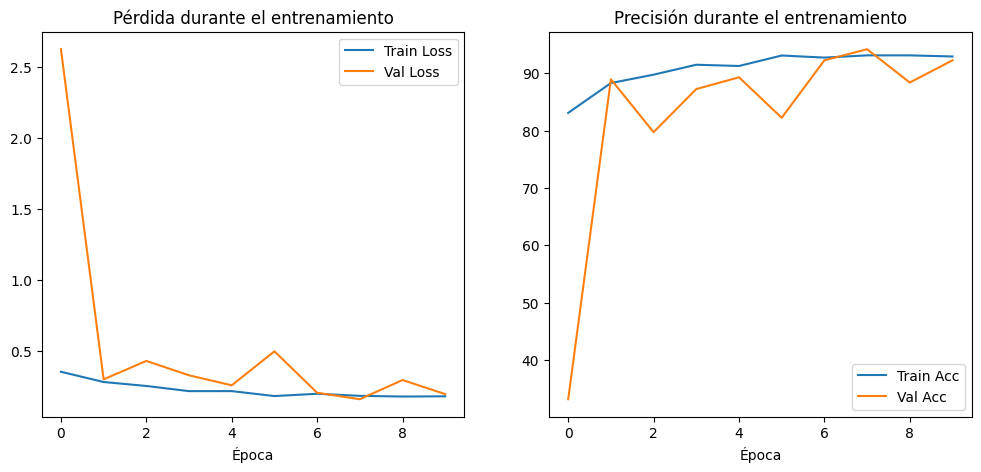

CPU times: user 5min 21s, sys: 9.6 s, total: 5min 31s
Wall time: 14min 22s


In [ ]:
%%time
# Entrenamiento con guardado del mejor modelo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Se usa el GPU en lugar de CPU si exite
model = PneumoniaResNet(num_classes=2).to(device) # se envia el modelo a GPU para realizar su ejecución
criterion = nn.CrossEntropyLoss()       # Se define la función de Perdida CrossEntropy
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Se define el Optimizador y el Learning Rate

num_epochs = 10                   # Se define el número de Epocas en 10
train_losses, val_losses = [], [] # Listas para guardar los costos
train_accuracies, val_accuracies = [], [] # Listas para guardar la presición

# Inicializamos en 0 los indicadores para el mejor modelo
best_val_acc = 0.0
best_epoch = 0

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    total_loss, correct, total = 0, 0, 0 # Inicializamos valores
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Envia a GPU
        optimizer.zero_grad() # Reinicia gradiente
        outputs = model(images) # logits o las salidas crudas
        loss = criterion(outputs, labels) # Calcula la perdida
        loss.backward() # Calcula los gradientes de cada parámetro del modelo respecto a la pérdida.
        optimizer.step() # Modifica los pesos del modelo según los gradientes y el optimizador

# Métricas de rendimiento
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # Validación
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad(): # Desactiva el cálculo de gradientes
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # Envia a GPU
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)         #Calcula con las salidas crudas las predicciones, toma la clase con mayor probabilidad
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Guardar el mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Nuevo mejor modelo guardado en epoch {best_epoch} con Val Acc: {best_val_acc*100:.2f}%")

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")


# Resultados finales

print(f"\n Entrenamiento completado.")
print(f"Mejor modelo: epoch {best_epoch} con Val Accuracy = {best_val_acc*100:.2f}%")


# Gráficas completas

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.array(train_accuracies)*100, label='Train Acc')
plt.plot(np.array(val_accuracies)*100, label='Val Acc')
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.legend()
plt.show()



En la gráfica de precisión, se aprecia que la exactitud de entrenamiento aumenta de manera sostenida, alcanzando valores cercanos al 93%, mientras que la precisión de validación también mejora significativamente, llegando aproximadamente al 90%. Las fluctuaciones leves en la validación son normales y reflejan variaciones propias del conjunto de datos, sin indicar un sobreajuste importante.

En general, el modelo presenta un entrenamiento exitoso, con una buena capacidad de generalización y un rendimiento consistente entre entrenamiento y validación. Se recomienda, para futuras iteraciones, aumentar ligeramente el número de épocas o aplicar técnicas de aumento de datos (data augmentation) para verificar si es posible mejorar aún más la estabilidad y el desempeño del modelo.

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy en Test: {acc*100:.2f}%")

pres = precision_score(y_true, y_pred)
print(f" Precisión en Test: {pres*100:.2f}%")

recalls = recall_score(y_true, y_pred)
print(f" Recall_score en Test: {recalls*100:.2f}%")

f1s = f1_score(y_true, y_pred)
print(f" F1_score en Test: {f1s*100:.2f}%")

Accuracy en Test: 92.83%
 Precisión en Test: 94.19%
 Recall_score en Test: 96.10%
 F1_score en Test: 95.14%


Class names: ['NORMAL', 'PNEUMONIA']


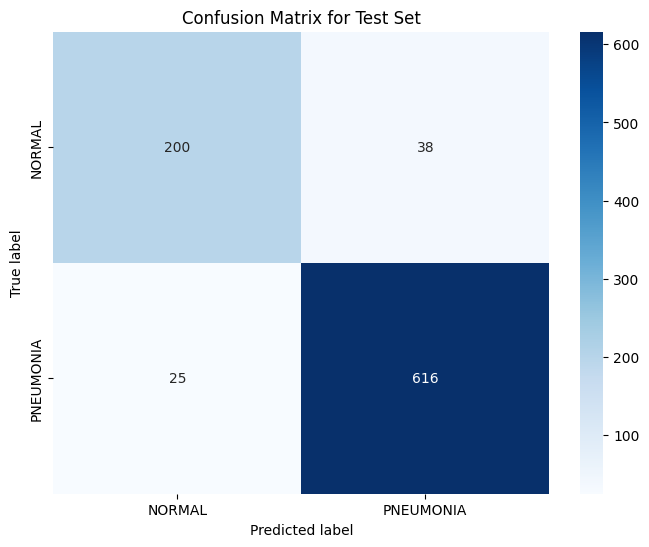

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Get class names from the dataset
class_names = test_data.classes
print("Class names:", class_names)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Test Set')
plt.show()

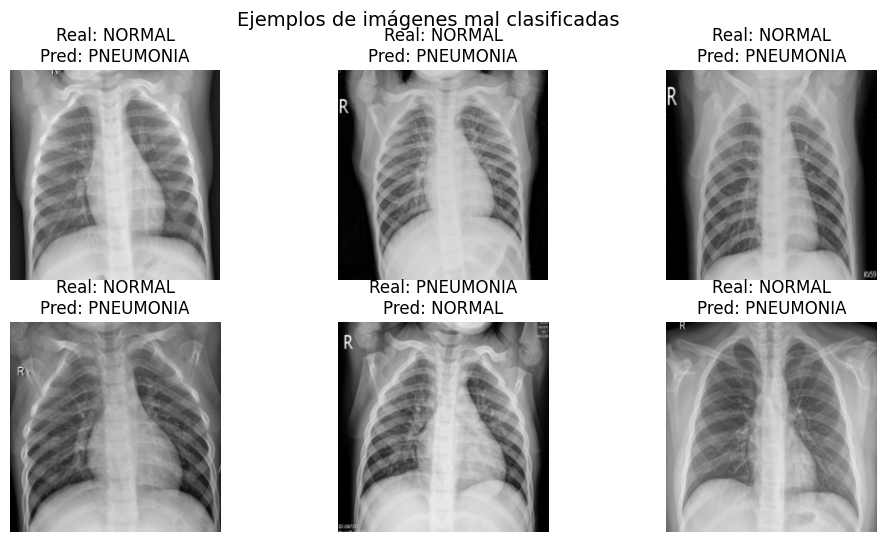

In [ ]:
# Visualizar imágenes mal clasificadas

import random

misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for img, label, pred in zip(images, labels, preds):
            if label != pred:
                misclassified.append((img.cpu(), label.cpu(), pred.cpu()))

# Mostrar algunas imágenes mal clasificadas
num_images = min(6, len(misclassified))
if num_images > 0:
    plt.figure(figsize=(12, 6))
    for i in range(num_images):
        img, label, pred = random.choice(misclassified)
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"Real: {test_data.classes[label]}\nPred: {test_data.classes[pred]}")
        plt.axis('off')
    plt.suptitle("Ejemplos de imágenes mal clasificadas", fontsize=14)
    plt.show()
else:
    print(" No hubo imágenes mal clasificadas en el conjunto de prueba.")
